In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df=pd.read_csv("C:/Users/galib/Downloads/archive (13)/job_salary_prediction_dataset.csv")

In [3]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [5]:
df["job_title"].unique()

array(['AI Engineer', 'Data Analyst', 'Frontend Developer',
       'Business Analyst', 'Product Manager', 'Backend Developer',
       'Machine Learning Engineer', 'DevOps Engineer',
       'Software Engineer', 'Cybersecurity Analyst', 'Data Scientist',
       'Cloud Engineer'], dtype=object)

In [6]:
df["education_level"].unique()

array(['Bachelor', 'PhD', 'High School', 'Diploma', 'Master'],
      dtype=object)

In [7]:
df["industry"].unique()

array(['Healthcare', 'Telecom', 'Media', 'Retail', 'Manufacturing',
       'Education', 'Finance', 'Technology', 'Consulting', 'Government'],
      dtype=object)

In [8]:
df["company_size"].unique()

array(['Medium', 'Small', 'Large', 'Enterprise', 'Startup'], dtype=object)

In [9]:
df["location"].unique()

array(['India', 'Australia', 'Singapore', 'Canada', 'Sweden', 'USA',
       'Netherlands', 'Remote', 'Germany', 'UK'], dtype=object)

In [10]:
df["remote_work"].unique()

array(['Hybrid', 'No', 'Yes'], dtype=object)

In [11]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [12]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

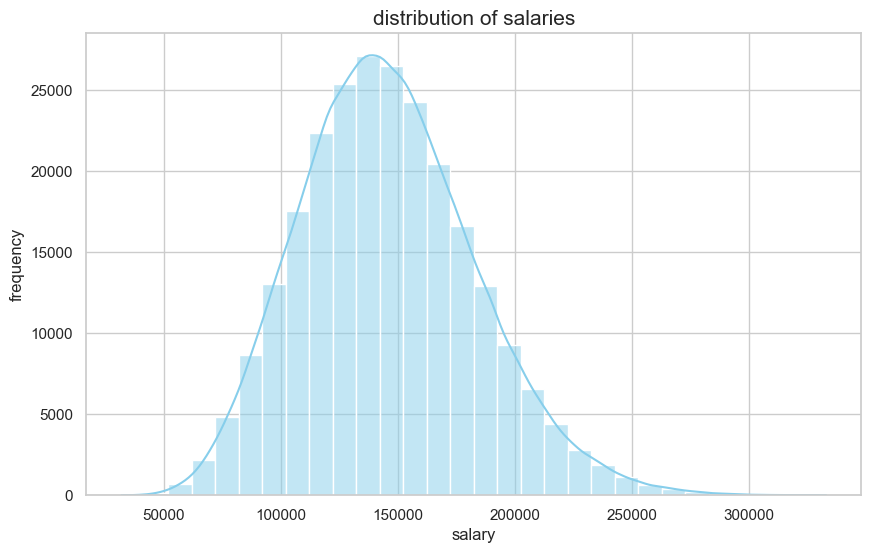

In [13]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
sns.histplot(df["salary"],kde=True,
            color="skyblue", bins=30)
plt.title("distribution of salaries", fontsize=15)
plt.xlabel("salary", fontsize=12)
plt.ylabel("frequency", fontsize=12)
plt.show()

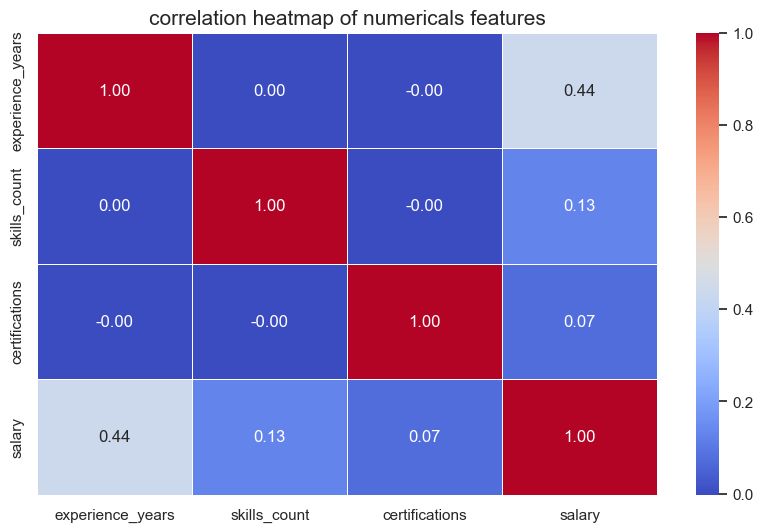

In [14]:
numerical_df=df.select_dtypes(include=["int64", "float64"])
corr_matrix=numerical_df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True,
           cmap="coolwarm", fmt=".2f",
           linewidths=.5)
plt.title("correlation heatmap of numericals features", fontsize=15)
plt.savefig("correlation_heatmap.png")

In [15]:
from sklearn.preprocessing import LabelEncoder

In [16]:
education_map = {
    'Diploma': 1, 
    'High School': 2, 
    'Bachelor': 3, 
    'Master': 4, 
    'PhD': 5
}
company_size_map = {
    'Startup': 1, 
    'Small': 2, 
    'Medium': 3, 
    'Large': 4, 
    'Enterprise': 5
}

df['education_level'] = df['education_level'].map(education_map)
df['company_size'] = df['company_size'].map(company_size_map)

In [17]:
df_final = pd.get_dummies(df, columns=['job_title', 'industry', 'location', 'remote_work'], drop_first=True)

In [18]:
df_final = df_final.astype(float)

In [19]:
df = pd.concat([df, df_final], axis=1)

In [20]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,AI Engineer,10,3,2,Healthcare,3,India,Hybrid,2,109413,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Data Analyst,5,3,17,Telecom,2,Australia,No,0,93764,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,Frontend Developer,18,5,4,Media,3,Singapore,No,1,148123,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,Business Analyst,19,5,13,Retail,3,Canada,Yes,0,189123,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,Product Manager,15,3,7,Manufacturing,4,Sweden,Yes,0,165069,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [21]:
df = df.drop(['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work'], axis=1)

In [22]:
df.head()

,experience_years,skills_count,certifications,salary,experience_years,skills_count,certifications,salary,job_title_Backend Developer,job_title_Business Analyst,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,109413,10.0,2.0,2.0,109413.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5,17,0,93764,5.0,17.0,0.0,93764.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,18,4,1,148123,18.0,4.0,1.0,148123.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,19,13,0,189123,19.0,13.0,0.0,189123.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,15,7,0,165069,15.0,7.0,0.0,165069.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


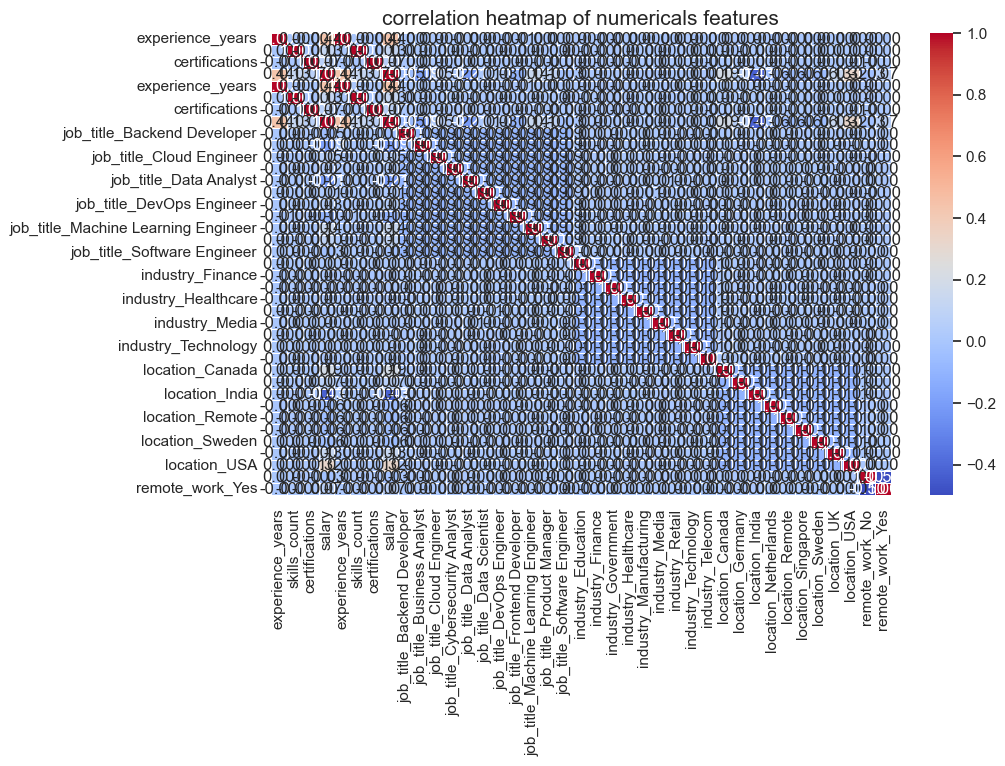

In [23]:
numerical_df=df.select_dtypes(include=["int64", "float64"])
corr_matrix=numerical_df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True,
           cmap="coolwarm", fmt=".2f",
           linewidths=.5)
plt.title("correlation heatmap of numericals features", fontsize=15)
plt.savefig("correlation_heatmap.png")

In [24]:
df.head()

,experience_years,skills_count,certifications,salary,experience_years,skills_count,certifications,salary,job_title_Backend Developer,job_title_Business Analyst,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,109413,10.0,2.0,2.0,109413.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5,17,0,93764,5.0,17.0,0.0,93764.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,18,4,1,148123,18.0,4.0,1.0,148123.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,19,13,0,189123,19.0,13.0,0.0,189123.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,15,7,0,165069,15.0,7.0,0.0,165069.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [25]:
df = df.loc[:, ~df.columns.duplicated()]

In [26]:
df.head()

,experience_years,skills_count,certifications,salary,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,109413,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5,17,0,93764,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,18,4,1,148123,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,19,13,0,189123,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,15,7,0,165069,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


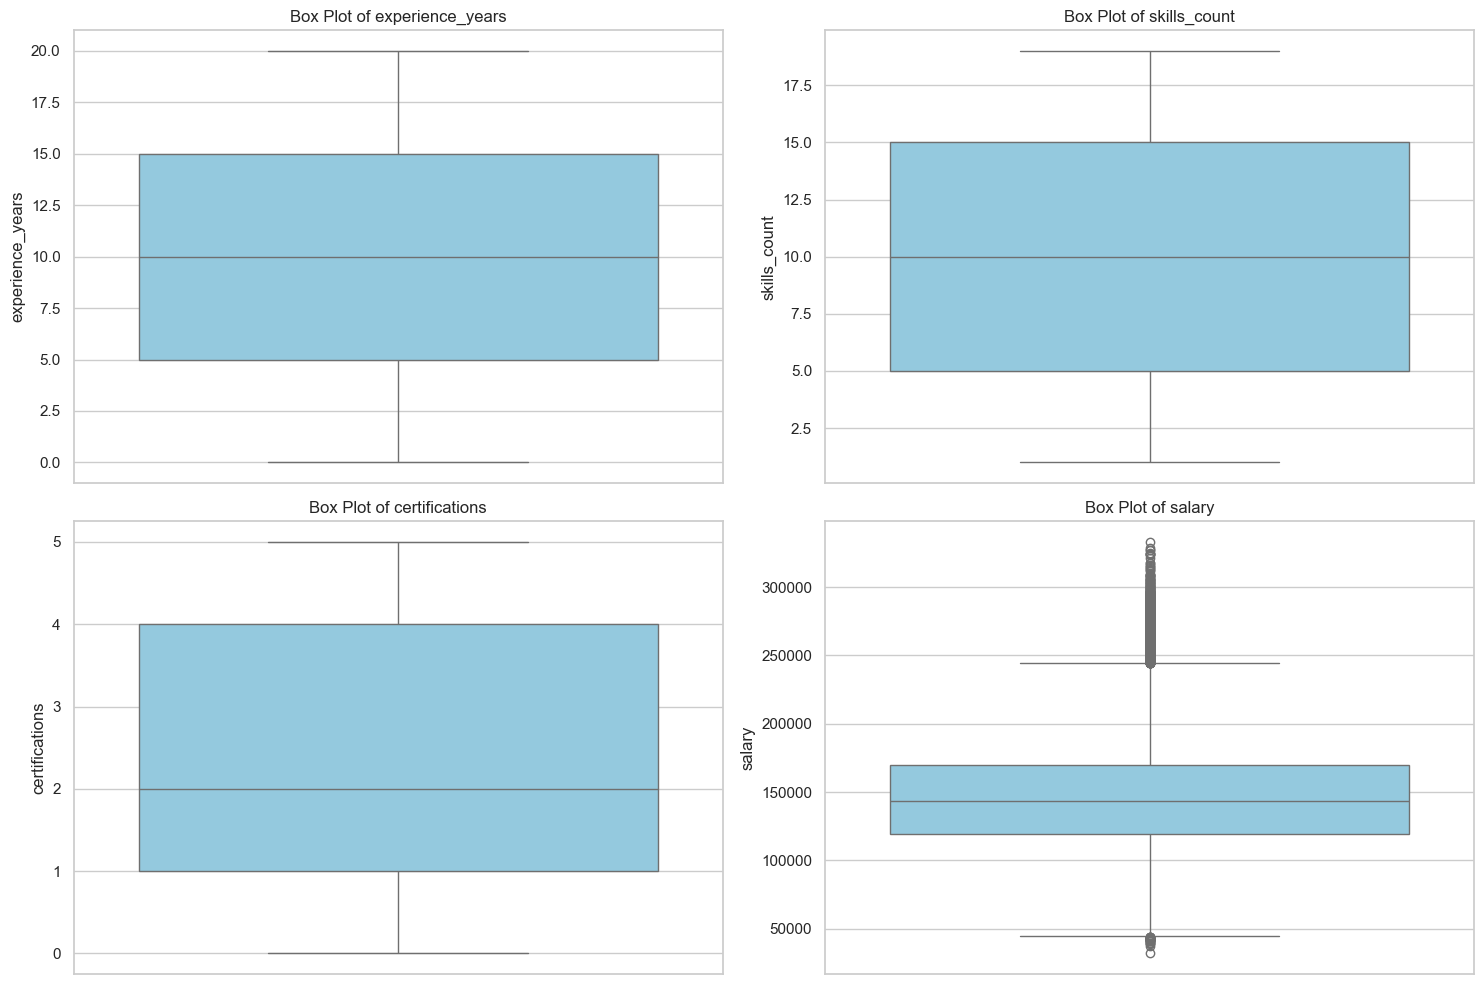

In [27]:
numerical_cols = ['experience_years', 'skills_count', 'certifications', 'salary']

# Create a figure with subplots
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    # y=df[col] creates a vertical box plot
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Box Plot of {col}')

plt.tight_layout()
plt.savefig('numerical_boxplots.png')
plt.show()

In [28]:
numerical_cols = ['experience_years', 'skills_count', 'certifications', 'salary']

print("--- Outlier Detection Report ---")

for col in numerical_cols:
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    # Calculate the Interquartile Range (IQR)
    IQR = Q3 - Q1
    
    # Define the Upper and Lower Bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count how many values fall outside these bounds
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    count = len(outliers)
    
    print(f"{col}: {count} outliers found")

--- Outlier Detection Report ---
experience_years: 0 outliers found
skills_count: 0 outliers found
certifications: 0 outliers found
salary: 2336 outliers found


In [29]:
df['salary'] = np.log1p(df['salary'])

In [30]:
df

,experience_years,skills_count,certifications,salary,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,11.602894,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5,17,0,11.448547,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,18,4,1,11.905805,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,19,13,0,12.150158,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,15,7,0,12.014125,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,17,2,1,11.758159,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
249996,20,7,2,11.948558,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
249997,1,12,0,11.238344,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
249998,0,2,5,11.412751,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['experience_years', 'skills_count', 'certifications']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [32]:
df

,experience_years,skills_count,certifications,salary,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,-0.000892,-1.459647,-0.288272,11.602894,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.825894,1.277940,-1.460281,11.448547,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.319111,-1.094636,-0.874276,11.905805,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,1.484112,0.547917,-1.460281,12.150158,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.824110,-0.547118,-1.460281,12.014125,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,1.154111,-1.459647,-0.874276,11.758159,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
249996,1.649112,-0.547118,-0.288272,11.948558,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
249997,-1.485896,0.365411,-1.460281,11.238344,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
249998,-1.650897,-1.459647,1.469741,11.412751,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
